In [1]:
!pip install -q torch torchvision scikit-learn pandas matplotlib tqdm pillow

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import ConvNeXt_Tiny_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROCESSED_BASE_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb_clahe"

DIABETES_DIR = os.path.join(PROCESSED_BASE_DIR, "diabetes")
NONDIABETES_DIR = os.path.join(PROCESSED_BASE_DIR, "nondiabetes")

print("Diabetes dir exists:", os.path.exists(DIABETES_DIR))
print("Non-diabetes dir exists:", os.path.exists(NONDIABETES_DIR))

Diabetes dir exists: True
Non-diabetes dir exists: True


In [6]:
def build_dataframe(diabetes_dir, nondiabetes_dir):
    rows = []

    for img_path in sorted(Path(diabetes_dir).glob("*")):
        if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
            rows.append({
                "image_path": str(img_path),
                "label": 1,
                "label_name": "diabetes"
            })

    for img_path in sorted(Path(nondiabetes_dir).glob("*")):
        if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
            rows.append({
                "image_path": str(img_path),
                "label": 0,
                "label_name": "nondiabetes"
            })

    return pd.DataFrame(rows)

df = build_dataframe(DIABETES_DIR, NONDIABETES_DIR)

print("Total samples:", len(df))
print(df["label_name"].value_counts())
df.head()

Total samples: 957
label_name
nondiabetes    519
diabetes       438
Name: count, dtype: int64


,image_path,label,label_name
0,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
1,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
2,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
3,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes
4,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes


In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["label_name"].value_counts())

print("\nVal distribution:")
print(val_df["label_name"].value_counts())

print("\nTest distribution:")
print(test_df["label_name"].value_counts())

Train: 669
Val: 144
Test: 144

Train distribution:
label_name
nondiabetes    363
diabetes       306
Name: count, dtype: int64

Val distribution:
label_name
nondiabetes    78
diabetes       66
Name: count, dtype: int64

Test distribution:
label_name
nondiabetes    78
diabetes       66
Name: count, dtype: int64


In [8]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
class TongueDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

In [11]:
train_dataset = TongueDataset(train_df, transform=train_transform)
val_dataset = TongueDataset(val_df, transform=eval_transform)
test_dataset = TongueDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 42
Val batches: 9
Test batches: 9


In [12]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:8])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Sample labels: tensor([0., 0., 1., 0., 0., 1., 1., 1.])


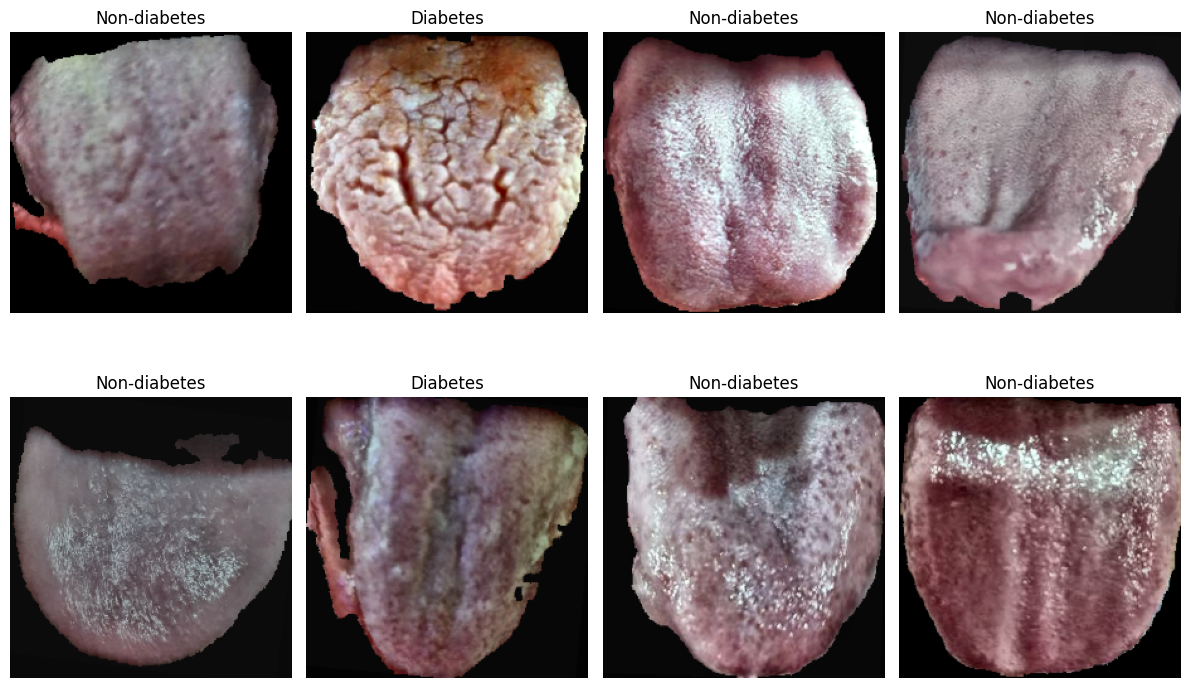

In [13]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    return img_tensor

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title("Diabetes" if labels[i].item() == 1 else "Non-diabetes")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = models.convnext_tiny(weights=weights)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 176MB/s]


In [15]:
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, 1)

model = model.to(DEVICE)
print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1, bias=True)
)


In [16]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [17]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable_params)
print("Total params:", total_params)

Trainable params: 2305
Total params: 27820897


In [18]:
class_counts = train_df["label"].value_counts().sort_index()
num_negative = class_counts[0]
num_positive = class_counts[1]

pos_weight = torch.tensor([num_negative / num_positive], dtype=torch.float32).to(DEVICE)
print("pos_weight:", pos_weight.item())

pos_weight: 1.186274528503418


In [19]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        all_probs.extend(probs)
        all_labels.extend(labels.detach().cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)

    acc = accuracy_score(all_labels, preds)
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, acc, precision, recall, f1, auc

In [21]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)

    acc = accuracy_score(all_labels, preds)
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, acc, precision, recall, f1, auc, np.array(all_labels), np.array(all_probs)

In [22]:
EPOCHS_HEAD = 10

history = {
    "train_loss": [],
    "train_auc": [],
    "val_loss": [],
    "val_auc": []
}

best_val_auc = 0.0
best_model_path = "/content/drive/MyDrive/TongueImagediabetes/convnext_tiny_best_head.pth"

In [23]:
for epoch in range(EPOCHS_HEAD):
    print(f"\nEpoch {epoch+1}/{EPOCHS_HEAD}")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_loss, train_acc, train_precision, train_recall, train_f1, train_auc = train_metrics

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, _, _ = val_metrics

    history["train_loss"].append(train_loss)
    history["train_auc"].append(train_auc)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   AUC: {val_auc:.4f} | Val   F1: {val_f1:.4f}")

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_model_path)
        print("Best head model saved.")


Epoch 1/10


Train Loss: 0.6246 | Train AUC: 0.8073 | Train F1: 0.7117
Val   Loss: 0.5163 | Val   AUC: 0.8990 | Val   F1: 0.8143
Best head model saved.

Epoch 2/10


Train Loss: 0.4753 | Train AUC: 0.9088 | Train F1: 0.8170
Val   Loss: 0.4313 | Val   AUC: 0.9310 | Val   F1: 0.8201
Best head model saved.

Epoch 3/10


Train Loss: 0.4089 | Train AUC: 0.9328 | Train F1: 0.8325
Val   Loss: 0.3834 | Val   AUC: 0.9456 | Val   F1: 0.8321
Best head model saved.

Epoch 4/10


Train Loss: 0.3632 | Train AUC: 0.9493 | Train F1: 0.8666
Val   Loss: 0.3611 | Val   AUC: 0.9516 | Val   F1: 0.8281
Best head model saved.

Epoch 5/10


...

Train Loss: 0.3166 | Train AUC: 0.9602 | Train F1: 0.8724
Val   Loss: 0.3130 | Val   AUC: 0.9635 | Val   F1: 0.8676
Best head model saved.

Epoch 7/10


Train Loss: 0.2996 | Train AUC: 0.9631 | Train F1: 0.8813
Val   Loss: 0.3032 | Val   AUC: 0.9658 | Val   F1: 0.8661
Best head model saved.

Epoch 8/10


Train Loss: 0.2806 | Train AUC: 0.9694 | Train F1: 0.8841
Val   Loss: 0.2975 | Val   AUC: 0.9683 | Val   F1: 0.8730
Best head model saved.

Epoch 9/10


Train Loss: 0.2651 | Train AUC: 0.9721 | Train F1: 0.8889
Val   Loss: 0.2805 | Val   AUC: 0.9699 | Val   F1: 0.8906
Best head model saved.

Epoch 10/10


Train Loss: 0.2631 | Train AUC: 0.9695 | Train F1: 0.8990
Val   Loss: 0.2729 | Val   AUC: 0.9742 | Val   F1: 0.8841
Best head model saved.


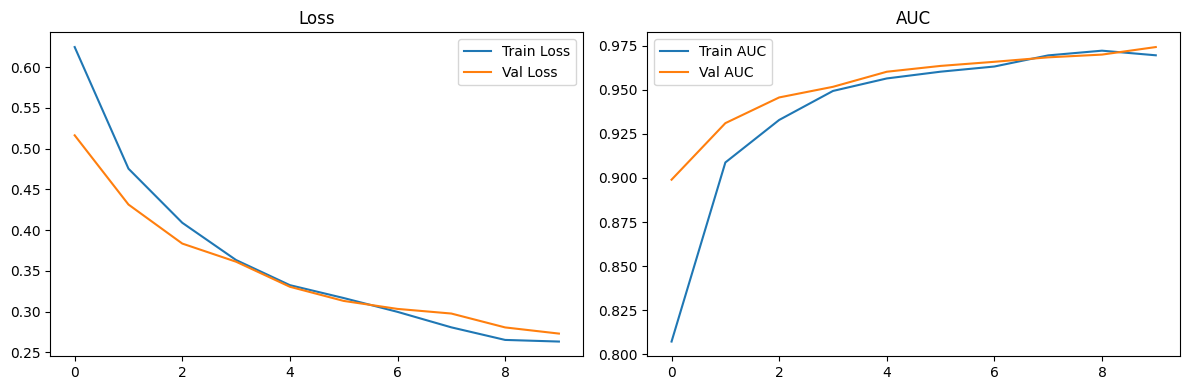

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["train_auc"], label="Train AUC")
plt.plot(history["val_auc"], label="Val AUC")
plt.legend()
plt.title("AUC")

plt.tight_layout()
plt.show()

In [25]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print("Best head model loaded.")

Best head model loaded.


In [26]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[6:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

In [27]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params after unfreezing final stage:", trainable_params)

Trainable params after unfreezing final stage: 15472897


In [28]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS_FINE = 10
best_finetuned_model_path = "/content/drive/MyDrive/TongueImagediabetes/convnext_tiny_best_finetuned.pth"
best_val_auc = 0.0

In [29]:
for epoch in range(EPOCHS_FINE):
    print(f"\nFine-tuning Epoch {epoch+1}/{EPOCHS_FINE}")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_loss, train_acc, train_precision, train_recall, train_f1, train_auc = train_metrics

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, _, _ = val_metrics

    print(f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   AUC: {val_auc:.4f} | Val   F1: {val_f1:.4f}")

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_finetuned_model_path)
        print("Best fine-tuned model saved.")


Fine-tuning Epoch 1/10


Train Loss: 0.2541 | Train AUC: 0.9675 | Train F1: 0.8853
Val   Loss: 0.1978 | Val   AUC: 0.9802 | Val   F1: 0.8960
Best fine-tuned model saved.

Fine-tuning Epoch 2/10


Train Loss: 0.1267 | Train AUC: 0.9921 | Train F1: 0.9608
Val   Loss: 0.1372 | Val   AUC: 0.9909 | Val   F1: 0.9385
Best fine-tuned model saved.

Fine-tuning Epoch 3/10


Train Loss: 0.0625 | Train AUC: 0.9981 | Train F1: 0.9804
Val   Loss: 0.1428 | Val   AUC: 0.9916 | Val   F1: 0.9365
Best fine-tuned model saved.

Fine-tuning Epoch 4/10


Train Loss: 0.0541 | Train AUC: 0.9988 | Train F1: 0.9836
Val   Loss: 0.1095 | Val   AUC: 0.9940 | Val   F1: 0.9552
Best fine-tuned model saved.

Fine-tuning Epoch 5/10


...

Train Loss: 0.0230 | Train AUC: 0.9998 | Train F1: 0.9935
Val   Loss: 0.1249 | Val   AUC: 0.9932 | Val   F1: 0.9403

Fine-tuning Epoch 7/10


Train Loss: 0.0185 | Train AUC: 0.9999 | Train F1: 0.9951
Val   Loss: 0.1672 | Val   AUC: 0.9915 | Val   F1: 0.9291

Fine-tuning Epoch 8/10


Train Loss: 0.0125 | Train AUC: 1.0000 | Train F1: 0.9951
Val   Loss: 0.1289 | Val   AUC: 0.9924 | Val   F1: 0.9403

Fine-tuning Epoch 9/10


Train Loss: 0.0079 | Train AUC: 1.0000 | Train F1: 1.0000
Val   Loss: 0.1329 | Val   AUC: 0.9928 | Val   F1: 0.9313

Fine-tuning Epoch 10/10


Train Loss: 0.0043 | Train AUC: 1.0000 | Train F1: 1.0000
Val   Loss: 0.1222 | Val   AUC: 0.9930 | Val   F1: 0.9474


In [30]:
model.load_state_dict(torch.load(best_finetuned_model_path, map_location=DEVICE))
model.eval()
print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


In [31]:
from sklearn.metrics import f1_score, recall_score, precision_score

def find_best_threshold(y_true, y_probs, metric="f1"):
    thresholds = np.arange(0.10, 0.91, 0.01)

    best_threshold = 0.50
    best_score = -1
    results = []

    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        else:
            raise ValueError("metric must be 'f1', 'recall', or 'precision'")

        results.append((t, score))

        if score > best_score:
            best_score = score
            best_threshold = t

    return best_threshold, best_score, results

In [32]:
val_loss, val_acc, val_precision, val_recall, val_f1, val_auc, y_val_true, y_val_probs = evaluate(
    model, val_loader, criterion, DEVICE
)

best_threshold, best_val_f1_at_threshold, threshold_results = find_best_threshold(
    y_val_true,
    y_val_probs,
    metric="f1"
)

print(f"Best threshold from validation set: {best_threshold:.2f}")
print(f"Best validation F1 at this threshold: {best_val_f1_at_threshold:.4f}")

Best threshold from validation set: 0.46
Best validation F1 at this threshold: 0.9552


In [33]:
test_loss, _, _, _, _, _, y_true, y_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

y_pred = (y_probs >= best_threshold).astype(int)

test_acc = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, zero_division=0)
test_recall = recall_score(y_true, y_pred, zero_division=0)
test_f1 = f1_score(y_true, y_pred, zero_division=0)
test_auc = roc_auc_score(y_true, y_probs)

print(f"Chosen Threshold: {best_threshold:.2f}")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test AUC-ROC:   {test_auc:.4f}")

Chosen Threshold: 0.46
Test Loss:      0.1848
Test Accuracy:  0.9236
Test Precision: 0.8986
Test Recall:    0.9394
Test F1-score:  0.9185
Test AUC-ROC:   0.9827


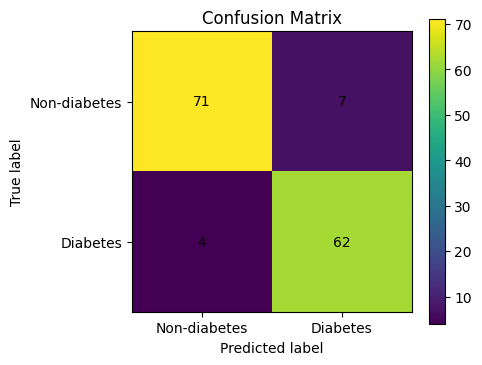

In [34]:
cm = confusion_matrix(y_true, y_pred)
cm

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Non-diabetes", "Diabetes"])
plt.yticks(tick_marks, ["Non-diabetes", "Diabetes"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [35]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-diabetes", "Diabetes"],
    digits=4
))

              precision    recall  f1-score   support

Non-diabetes     0.9467    0.9103    0.9281        78
    Diabetes     0.8986    0.9394    0.9185        66

    accuracy                         0.9236       144
   macro avg     0.9226    0.9248    0.9233       144
weighted avg     0.9246    0.9236    0.9237       144



In [36]:
test_results_df = test_df.copy()
test_results_df["true_label"] = y_true.astype(int)
test_results_df["pred_prob_diabetes"] = y_probs
test_results_df["pred_label"] = y_pred

save_csv_path = "/content/drive/MyDrive/TongueImagediabetes/convnext_tiny_test_predictions.csv"
test_results_df.to_csv(save_csv_path, index=False)

print("Saved test predictions to:", save_csv_path)
test_results_df.head()

Saved test predictions to: /content/drive/MyDrive/TongueImagediabetes/convnext_tiny_test_predictions.csv


,image_path,label,label_name,true_label,pred_prob_diabetes,pred_label
0,/content/drive/MyDrive/TongueImagediabetes/dat...,1,diabetes,1,0.999403,1
1,/content/drive/MyDrive/TongueImagediabetes/dat...,0,nondiabetes,0,0.000613,0
2,/content/drive/MyDrive/TongueImagediabetes/dat...,0,nondiabetes,0,0.005719,0
3,/content/drive/MyDrive/TongueImagediabetes/dat...,0,nondiabetes,0,0.000475,0
4,/content/drive/MyDrive/TongueImagediabetes/dat...,0,nondiabetes,0,0.751615,1
